# BC03 — Explicabilité SHAP du modèle LightGBM retenu

Complète l'importance par gain (figure 5 du rapport) par une lecture SHAP :
le **sens** de l'impact de chaque variable (pas seulement son ampleur
agrégée), et l'explication d'une décision individuelle — la brique qui
répond concrètement à l'exigence RGPD Art. 22 (explicabilité d'une décision
automatisée aux effets significatifs, au niveau de CHAQUE décision, pas
seulement en moyenne sur le portefeuille).

Réutilise le modèle déjà entraîné par `entrainement_modeles.ipynb` : exécuter
ce notebook après lui (le split temporel et le chargement des données sont
repris ici à l'identique, pour rester un notebook autonome).

In [1]:
import json
import logging
import os

import joblib
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import shap
from dotenv import load_dotenv

load_dotenv()
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)-7s | %(message)s")
log = logging.getLogger("bc03-shap")

BASE_DIR = os.path.join(os.getcwd(), "..")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
MODEL_DIR = os.path.join(BASE_DIR, "models")

NUMERIC_FEATURES = ["montant", "distance_domicile_km", "revenu_mensuel_net", "heure", "jour_semaine", "mois"]
BINARY_FEATURES = ["is_weekend", "is_nuit"]
CATEGORICAL_FEATURES = ["authentification", "canal", "segment"]
FEATURE_COLUMNS = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

N_ECHANTILLON = 3000  # taille de l'échantillon pour le résumé SHAP global

In [2]:
# Suivi MLflow — même expérience que entrainement_modeles.ipynb (voir mlflow_projet.py).
import sys

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
from mlflow_projet import init_mlflow

import mlflow

TRACKING_URI = init_mlflow("bc03_modeles_supervises")
log.info("Suivi MLflow actif : %s", TRACKING_URI)

2026-09-10 11:13:14,998 | INFO    | Suivi MLflow actif : http://localhost:5001


## Chargement des données (même requête et même split temporel que `entrainement_modeles.ipynb`)

In [3]:
def get_connection():
    return psycopg2.connect(
        host=os.getenv("POSTGRES_HOST", "localhost"), port=os.getenv("POSTGRES_PORT", "5434"),
        dbname=os.getenv("POSTGRES_DB", "frauddetect"), user=os.getenv("POSTGRES_USER", "fraud_admin"),
        password=os.getenv("POSTGRES_PASSWORD", "fraud_secret"),
    )


def charger_donnees() -> pd.DataFrame:
    query = """
        SELECT
            f.montant, f.distance_domicile_km, f.authentification, f.is_fraud,
            c.segment, c.revenu_mensuel_net,
            t.horodatage, t.heure, t.jour_semaine, t.is_weekend, t.is_nuit, t.mois,
            ca.canal
        FROM dwh.fact_transactions f
        JOIN dwh.dim_clients c ON c.client_key = f.client_key
        JOIN dwh.dim_temps t   ON t.temps_key = f.temps_key
        JOIN dwh.dim_canal ca  ON ca.canal_key = f.canal_key
        WHERE f.mode_ingestion = 'batch'
        ORDER BY t.horodatage;
    """
    conn = get_connection()
    df = pd.read_sql(query, conn)
    conn.close()
    df["is_weekend"] = df["is_weekend"].astype(int)
    df["is_nuit"] = df["is_nuit"].astype(int)
    return df


def split_temporel(df: pd.DataFrame, ratio_train: float = 0.8):
    idx = int(len(df) * ratio_train)
    return df.iloc[:idx], df.iloc[idx:]


def vers_explication_binaire(expl: shap.Explanation) -> shap.Explanation:
    """Normalise la sortie SHAP (les versions/API renvoient parfois une
    dimension supplémentaire par classe) vers la classe positive (fraude)."""
    values = expl.values
    base_values = expl.base_values
    if values.ndim == 3:
        values = values[:, :, 1]
    if np.ndim(base_values) >= 1 and np.ndim(base_values) == 2:
        base_values = base_values[:, 1]
    return shap.Explanation(
        values=values, base_values=base_values, data=expl.data, feature_names=expl.feature_names,
    )

In [4]:
df = charger_donnees()
_, test = split_temporel(df)
X_test = test[FEATURE_COLUMNS].reset_index(drop=True)
y_test = test["is_fraud"].astype(int).reset_index(drop=True)

pipeline = joblib.load(os.path.join(MODEL_DIR, "modele_lightgbm.joblib"))
prep = pipeline.named_steps["prep"]
modele = pipeline.named_steps["clf"]
noms_features = (
    NUMERIC_FEATURES + BINARY_FEATURES
    + list(prep.named_transformers_["cat"].get_feature_names_out(CATEGORICAL_FEATURES))
)
log.info("Modèle et prétraitement chargés (%d features)", len(noms_features))

explainer = shap.TreeExplainer(modele)

C:\Users\user\AppData\Local\Temp\ipykernel_14292\3633277411.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
2026-09-10 11:13:35,746 | INFO    | Modèle et prétraitement chargés (18 features)


## 1. Vue globale — échantillon (le calcul SHAP est coûteux sur 80 000 lignes)

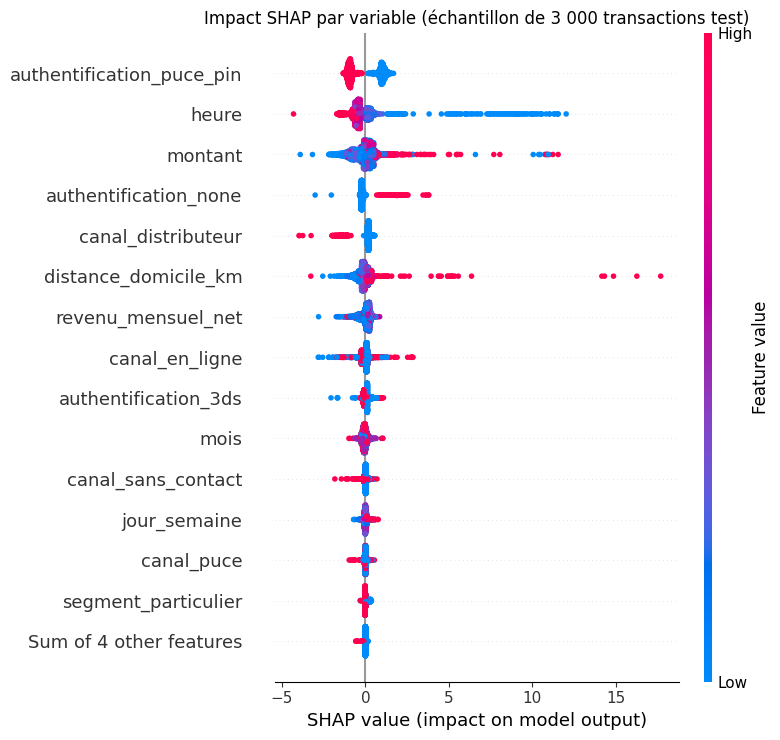

2026-09-10 11:13:57,428 | INFO    | Résumé SHAP (beeswarm) enregistré


In [5]:
echantillon = X_test.sample(n=min(N_ECHANTILLON, len(X_test)), random_state=42)
X_ech_enc = prep.transform(echantillon)
explication = vers_explication_binaire(explainer(X_ech_enc))
explication.feature_names = noms_features

plt.figure(figsize=(9, 6.5))
shap.plots.beeswarm(explication, max_display=15, show=False)
plt.title("Impact SHAP par variable (échantillon de 3 000 transactions test)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "06_shap_summary.png"), dpi=150, bbox_inches="tight")
plt.show()
log.info("Résumé SHAP (beeswarm) enregistré")

## 2. Décision individuelle

La fraude détectée avec la plus forte confiance, pour illustrer une
explication opposable au client / à l'équipe conformité (RGPD Art. 22).

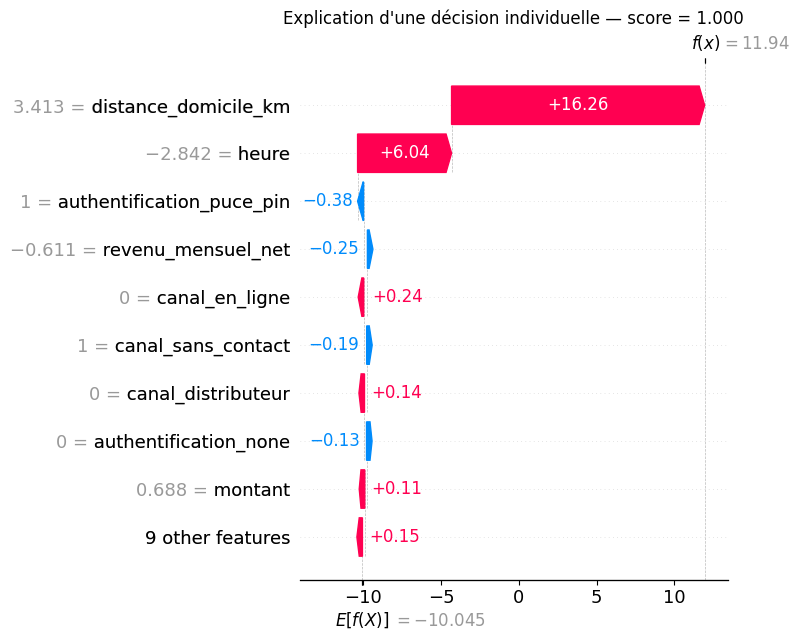

In [6]:
proba_test = pipeline.predict_proba(X_test)[:, 1]
est_vraie_fraude_bien_detectee = (y_test == 1) & (proba_test >= 0.5)
idx_exemple = int(np.argmax(np.where(est_vraie_fraude_bien_detectee, proba_test, -1)))

ligne_brute = X_test.iloc[[idx_exemple]]
ligne_enc = prep.transform(ligne_brute)
explication_ligne = vers_explication_binaire(explainer(ligne_enc))
explication_ligne.feature_names = noms_features

plt.figure(figsize=(8.5, 5.5))
shap.plots.waterfall(explication_ligne[0], max_display=10, show=False)
plt.title(f"Explication d'une décision individuelle — score = {proba_test[idx_exemple]:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "07_shap_decision_individuelle.png"), dpi=150, bbox_inches="tight")
plt.show()

## Résumé JSON

In [7]:
contributions = sorted(
    zip(noms_features, explication_ligne.values[0]), key=lambda t: abs(t[1]), reverse=True
)[:5]
exemple = {
    "score_predit": round(float(proba_test[idx_exemple]), 4),
    "valeurs_brutes": {c: (ligne_brute.iloc[0][c] if c in ligne_brute.columns else None)
                        for c in FEATURE_COLUMNS},
    "top_contributions_shap": [{"feature": f, "impact": round(float(v), 4)} for f, v in contributions],
}
log.info("Décision individuelle expliquée — score=%.4f, top facteurs : %s",
          proba_test[idx_exemple], [f for f, _ in contributions])

resume_path = os.path.join(OUTPUT_DIR, "resume_shap.json")
with open(resume_path, "w", encoding="utf-8") as f:
    json.dump(exemple, f, ensure_ascii=False, indent=2, default=str)

log.info("Explicabilité SHAP terminée — graphiques et résumé écrits dans %s", os.path.abspath(OUTPUT_DIR))
exemple

2026-09-10 11:14:14,912 | INFO    | Décision individuelle expliquée — score=1.0000, top facteurs : ['distance_domicile_km', 'heure', 'authentification_puce_pin', 'revenu_mensuel_net', 'canal_en_ligne']
2026-09-10 11:14:14,936 | INFO    | Explicabilité SHAP terminée — graphiques et résumé écrits dans c:\projet_expo\bc03_modeles_supervises\outputs


{'score_predit': 1.0,
 'valeurs_brutes': {'montant': 131.61,
  'distance_domicile_km': 175.22,
  'revenu_mensuel_net': 2074.33,
  'heure': 0,
  'jour_semaine': 1,
  'mois': 12,
  'is_weekend': 0,
  'is_nuit': 1,
  'authentification': 'puce_pin',
  'canal': 'sans_contact',
  'segment': 'particulier'},
 'top_contributions_shap': [{'feature': 'distance_domicile_km',
   'impact': 16.2583},
  {'feature': 'heure', 'impact': 6.0378},
  {'feature': 'authentification_puce_pin', 'impact': -0.3835},
  {'feature': 'revenu_mensuel_net', 'impact': -0.2475},
  {'feature': 'canal_en_ligne', 'impact': 0.2377}]}

In [8]:
# Rattache les artefacts d'explicabilité à l'expérience BC03 (run distinct, tag phase=explicabilite).
with mlflow.start_run(run_name="explicabilite_shap"):
    mlflow.set_tags({"bloc": "BC03", "phase": "explicabilite", "methode": "SHAP TreeExplainer"})
    mlflow.log_params({"n_echantillon_beeswarm": N_ECHANTILLON, "modele": "fraud_lightgbm"})
    mlflow.log_metric("score_decision_individuelle", float(proba_test[idx_exemple]))
    for fichier in ("06_shap_summary.png", "07_shap_decision_individuelle.png", "resume_shap.json"):
        mlflow.log_artifact(os.path.join(OUTPUT_DIR, fichier))
log.info("Artefacts SHAP journalisés dans MLflow — UI : %s", TRACKING_URI)

2026-09-10 11:14:17,387 | INFO    | Artefacts SHAP journalisés dans MLflow — UI : http://localhost:5001


🏃 View run explicabilite_shap at: http://localhost:5001/#/experiments/1/runs/5f0aa7ed20e24a57aec8eeec8c543748
🧪 View experiment at: http://localhost:5001/#/experiments/1
